In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn as sk

from sklearn.base             import BaseEstimator, ClassifierMixin, clone
from sklearn.tree             import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble         import BaggingClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.datasets         import make_classification, make_regression
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.utils            import resample, check_random_state

from catboost import CatBoostClassifier, Pool

import optuna

In [2]:
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
df.dtypes

id                       int64
age                    float64
height(cm)             float64
weight(kg)             float64
waist(cm)              float64
eyesight(left)         float64
eyesight(right)        float64
hearing(left)          float64
hearing(right)         float64
systolic               float64
relaxation             float64
fasting blood sugar    float64
Cholesterol            float64
triglyceride           float64
HDL                    float64
LDL                    float64
hemoglobin             float64
Urine protein          float64
serum creatinine       float64
AST                    float64
ALT                    float64
Gtp                    float64
dental caries          float64
smoking                float64
dtype: object

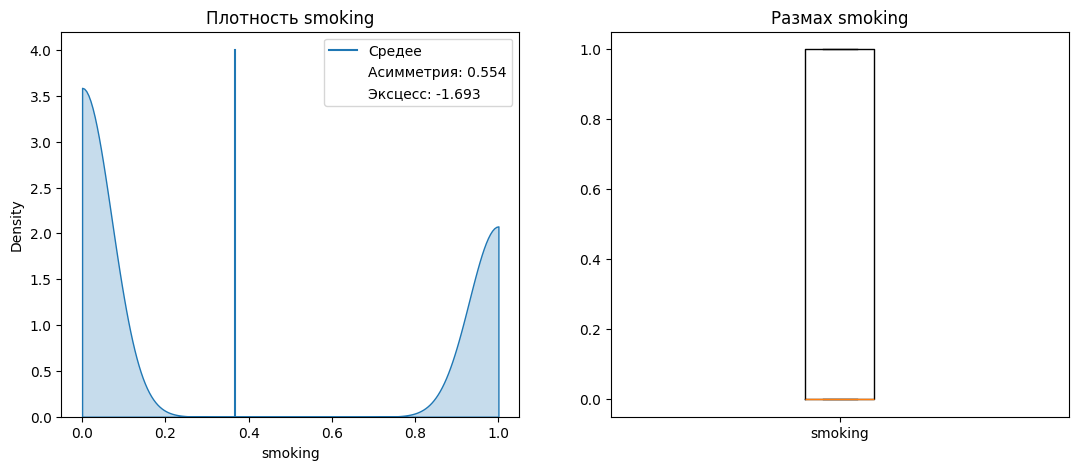

In [4]:
def build_distribution(values, column):
  sns.kdeplot(values, fill=True, cut=0)
  plt.plot([values.mean(), values.mean()], [0, np.max(plt.yticks()[0])], label='Средее')
  plt.scatter([], [], alpha=0, label=f'Асимметрия: {scipy.stats.skew(values):.3f}')
  plt.scatter([], [], alpha=0, label=f'Эксцесс: {scipy.stats.kurtosis(values):.3f}')
  plt.title(f'Плотность {column}')
  plt.legend()

plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
build_distribution(df['smoking'], 'smoking')
plt.subplot(1, 2, 2)
plt.boxplot(df['smoking'], tick_labels=['smoking'])
plt.title(f'Размах {'smoking'}')
plt.show()

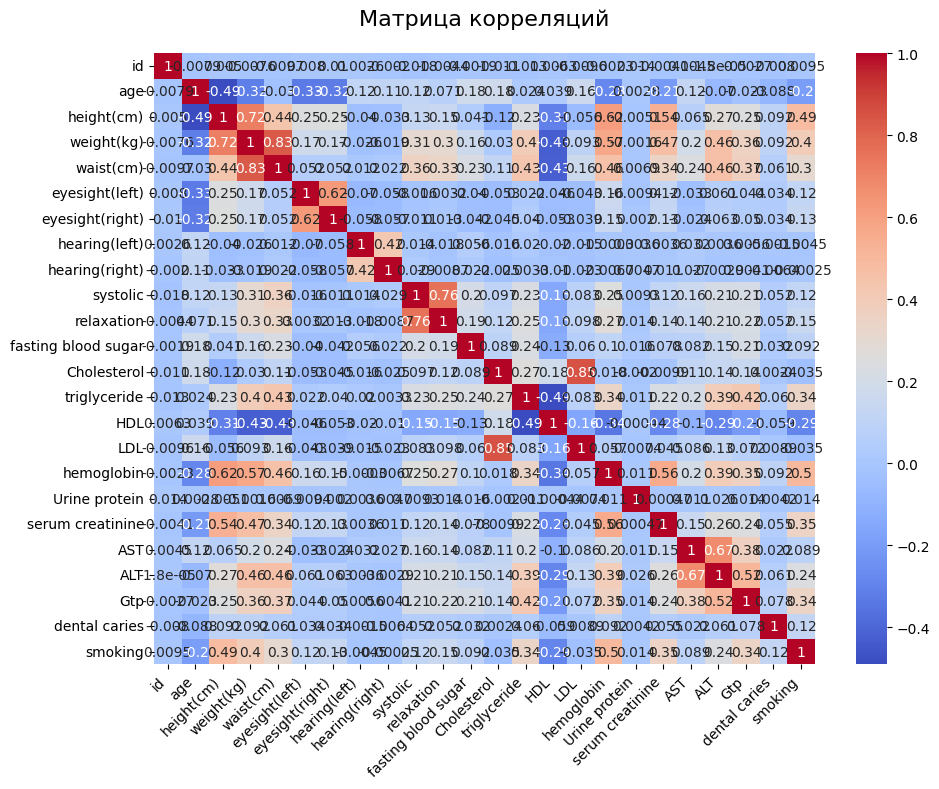

In [5]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
)
plt.title('Матрица корреляций', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Вычисляем корреляционную матрицу c связными значениями

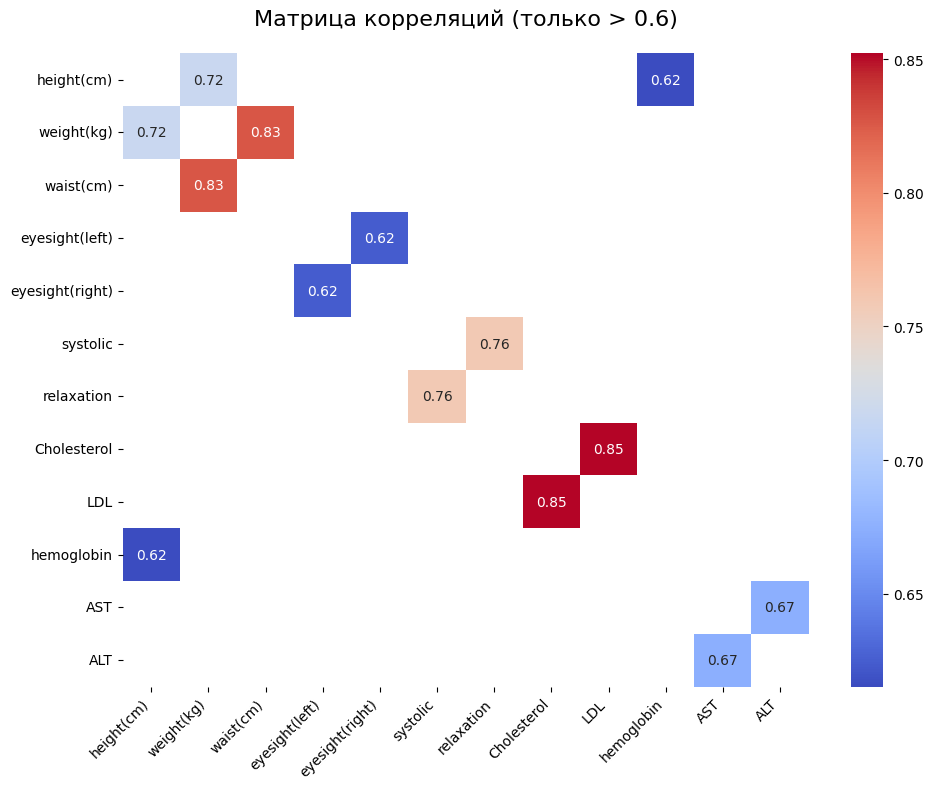

In [6]:
corr_matrix = df.corr()

filtered_corr = corr_matrix.where((corr_matrix > 0.6) & (corr_matrix < 1.0))

filtered_corr = filtered_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    filtered_corr,
    annot=True,
    cmap='coolwarm',
)
plt.title('Матрица корреляций (только > 0.6)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

BaggingClassifier

In [7]:
import numpy as np
from sklearn.base import clone

class MyBaggingClassifier:
    def __init__(self, base_estimator, n_estimators=10, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []
        self.estimators_samples_indices = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.models = []
        self.estimators_samples_indices = []
    
        for i in range(self.n_estimators):
            indices = np.random.choice(len(X), len(X), replace=True)
            X_sample = X.iloc[indices]
            y_sample = y.iloc[indices]
    
            model = clone(self.base_estimator)
            model.fit(X_sample, y_sample)
    
            self.models.append(model)
            self.estimators_samples_indices.append(indices)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])
        from scipy.stats import mode
        majority_votes, _ = mode(predictions, axis=0)
        return majority_votes.ravel()

    def predict_proba(self, X):
        all_probas = np.array([model.predict_proba(X) for model in self.models])
        avg_proba = np.mean(all_probas, axis=0)
        return avg_proba


In [8]:
X = df.drop(['id', 'smoking'], axis=1)
y = df['smoking']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = test_df.drop('id', axis=1)

In [9]:
base_estimator = DecisionTreeClassifier(max_depth=4)
my_bagging = MyBaggingClassifier(base_estimator=base_estimator, n_estimators=50, random_state=42)
my_bagging.fit(X_train, y_train)
my_pred = my_bagging.predict_proba(X_val)[:, 1]

sklearn_bagging = BaggingClassifier(base_estimator, n_estimators=50, random_state=42)
sklearn_bagging.fit(X_train, y_train)
sklearn_pred = sklearn_bagging.predict_proba(X_val)[:, 1]

print(f"My ROC-AUC:\t\t {roc_auc_score(y_val, my_pred)}")
print(f"Sklearn ROC-AUC:\t {roc_auc_score(y_val, sklearn_pred)}")

My ROC-AUC:		 0.8658106960950763
Sklearn ROC-AUC:	 0.8654951895868703


GradientBoostingClassifier

In [10]:
import numpy as np
from sklearn.base import clone

class MyGradientBoostingClassifier:
    def __init__(self, base_estimator, n_estimators=100, learning_rate=0.1):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.init_val = 0.0

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.models = []

        raw_predictions = np.full_like(y, fill_value=self.init_val, dtype=np.float64)

        for _ in range(self.n_estimators):
            p = self._sigmoid(raw_predictions)
            
            residuals = y - p

            model = clone(self.base_estimator)
            model.fit(X, residuals)

            update = model.predict(X)
            raw_predictions += self.learning_rate * update

            self.models.append(model)

    def predict_proba(self, X):
        X = np.array(X)
        raw_predictions = np.full(X.shape[0], fill_value=self.init_val, dtype=np.float64)
        for model in self.models:
            raw_predictions += self.learning_rate * model.predict(X)

        probs = self._sigmoid(raw_predictions)
        return np.vstack([1 - probs, probs]).T

    def predict(self, X):
        probas = self.predict_proba(X)
        return (probas[:, 1] >= 0.5).astype(int)


In [11]:
X = df.drop(['id', 'smoking'], axis=1)
y = df['smoking']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = df.drop('id', axis=1)

In [12]:
base_estimator = DecisionTreeRegressor(max_depth=4)
my_gb = MyGradientBoostingClassifier(base_estimator)
my_gb.fit(X_train, y_train)
my_pred = my_gb.predict_proba(X_val)[:, 1]

sklearn_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=4, random_state=42)
sklearn_gb.fit(X_train, y_train)
sklearn_pred = sklearn_gb.predict_proba(X_val)[:, 1]

print(f"\nMy ROC-AUC:\t\t {roc_auc_score(y_val, my_pred)}")
print(f"Sklearn ROC-AUC:\t {roc_auc_score(y_val, sklearn_pred)}")


My ROC-AUC:		 0.876282305225429
Sklearn ROC-AUC:	 0.8905154687794755


In [13]:
X = df.drop(['id', 'smoking'], axis=1)
y = df['smoking']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = test_df.drop('id', axis=1)

Сравнение

In [14]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
def compare_boosters(X_train, y_train, X_val, y_val):
    models = {
        "My GB": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
        "Sklearn GB": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
        "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
        "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, pred)
        results.append((name, auc))
        print(f"{name}: ROC-AUC = {auc:.4f}")

    return max(results, key=lambda x: x[1])

best_model_name, best_auc = compare_boosters(X_train, y_train, X_val, y_val)
print(f"\nThe best model: {best_model_name} с ROC-AUC = {best_auc:.4f}")

My GB: ROC-AUC = 0.8905
Sklearn GB: ROC-AUC = 0.8898
XGBoost: ROC-AUC = 0.8803
LightGBM: ROC-AUC = 0.8911
CatBoost: ROC-AUC = 0.8918

The best model: CatBoost с ROC-AUC = 0.8918


In [15]:
X = df.drop(['id', 'smoking'], axis=1)
y = df['smoking']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = test_df.drop('id', axis=1)

Подбор гипермараметров

In [17]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 6, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
    }

    model = CatBoostClassifier(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best AUC: ", study.best_value)
print("Best hyperparameters: ", study.best_params)


[I 2025-05-25 14:03:43,725] A new study created in memory with name: no-name-2b5eddc3-7162-4de7-8250-d5de078e1d14
[I 2025-05-25 14:03:46,312] Trial 0 finished with value: 0.8832314657611772 and parameters: {'iterations': 260, 'depth': 6, 'learning_rate': 0.010780710686395432}. Best is trial 0 with value: 0.8832314657611772.
[I 2025-05-25 14:03:47,669] Trial 1 finished with value: 0.8877655159403888 and parameters: {'iterations': 120, 'depth': 7, 'learning_rate': 0.03382440110244581}. Best is trial 1 with value: 0.8877655159403888.
[I 2025-05-25 14:04:06,609] Trial 2 finished with value: 0.8861611016789286 and parameters: {'iterations': 286, 'depth': 11, 'learning_rate': 0.008952472527863534}. Best is trial 1 with value: 0.8877655159403888.
[I 2025-05-25 14:04:24,569] Trial 3 finished with value: 0.884221844934918 and parameters: {'iterations': 276, 'depth': 11, 'learning_rate': 0.09002129877858758}. Best is trial 1 with value: 0.8877655159403888.
[I 2025-05-25 14:04:30,467] Trial 4 fin

Best AUC:  0.8877655159403888
Best hyperparameters:  {'iterations': 120, 'depth': 7, 'learning_rate': 0.03382440110244581}


Метрики

In [18]:
def my_accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def my_precision_score(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def my_recall_score(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def my_f1_score(y_true, y_pred):
    p = my_precision_score(y_true, y_pred)
    r = my_recall_score(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [19]:
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc_sk = accuracy_score(y_test, y_pred)
prec_sk = precision_score(y_test, y_pred)
rec_sk = recall_score(y_test, y_pred)
f1_sk = f1_score(y_test, y_pred)

acc_custom = my_accuracy_score(y_test, y_pred)
prec_custom = my_precision_score(y_test, y_pred)
rec_custom = my_recall_score(y_test, y_pred)
f1_custom = my_f1_score(y_test, y_pred)

print(f"Accuracy  (custom): {acc_custom:.4f} | Sklearn: {acc_sk:.4f}")
print(f"Precision (custom): {prec_custom:.4f} | Sklearn: {prec_sk:.4f}")
print(f"Recall    (custom): {rec_custom:.4f} | Sklearn: {rec_sk:.4f}")
print(f"F1-Score  (custom): {f1_custom:.4f} | Sklearn: {f1_sk:.4f}")


Accuracy  (custom): 0.9100 | Sklearn: 0.9100
Precision (custom): 0.9684 | Sklearn: 0.9684
Recall    (custom): 0.8598 | Sklearn: 0.8598
F1-Score  (custom): 0.9109 | Sklearn: 0.9109


Результат для kaggle

In [ ]:
X = df.drop(['id', 'smoking'], axis=1)
y = df['smoking']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = test_df.drop('id', axis=1)

model = CatBoostClassifier(n_estimators=1359, max_depth=8, learning_rate=0.007689944845816633, verbose=0)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]

df = np.array([test_df['id'], y_pred_proba]).transpose()
res = pd.DataFrame(data=df, columns=['id', 'smoking'])
res.to_csv('result.csv', index=False)